# 2.5b — Calibration des probabilités : reliability diagrams, ECE, et pourquoi 0.87 n'est pas 87 % de chances

**Navigation** : [<< 2.5-Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) | [Index](README.md) | [2.6-Clustering-KMeans-PCA >>](2.6-Clustering-KMeans-PCA.ipynb)

**Kernel** : Python 3

## Introduction

Le notebook 2.5 a montré comment évaluer un classifieur au-delà de l'accuracy : la **courbe ROC** et l'**AUC** mesurent la capacité du modèle à **ordonner** les exemples — lequel patient est plus à risque que lequel. Mais l'AUC ne dit rien d'une question très concrète : quand le modèle affiche **0.87** pour un patient, a-t-il **87 % de chances** d'être positif ? Rien n'est moins sûr. Beaucoup de modèles produisent des **scores** qui ordonnent bien les exemples mais ne se comportent pas comme des **probabilités**. La calibration est la propriété qui fait coïncider les deux — et elle se diagnostique, se mesure et se répare.

Ce notebook s'intercale entre 2.5 et 2.6 : nous restons dans le supervisé probabiliste (même jeu de données `breast_cancer` et même découpage 70/30 que 2.5) en ajoutant l'outil qui manquait — lire un score comme une probabilité digne de ce nom.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Distinguer **score discriminant** (ordonner) et **probabilité calibrée** (quantifier), et diagnostiquer un modèle mal calibré.
2. Construire un **reliability diagram** from scratch : binning, confiance moyenne vs fréquence observée.
3. Chiffrer la calibration par l'**ECE** (Expected Calibration Error) et le **Brier score**.
4. Recalibrer un modèle avec le **Platt scaling** et la **régression isotonique** — et comprendre ce que la calibration **ne change pas** (ordre, AUC).
5. Consommer des probabilités calibrées dans une **décision coût/bénéfice** (espérance de gain).

### Prérequis

- Notebook 2.1 (standardisation, train/test split, métriques).
- Notebook 2.3 (régression logistique, sigmoïde).
- Notebook 2.4 (forêts aléatoires).
- Notebook 2.5 (courbe ROC, AUC, seuil de décision).

> **Référence.** Niculescu-Mizil, A. & Caruana, R. (2005), *Predicting Good Probabilities With Supervised Learning*, ICML 2005. La régression logistique sort généralement bien calibrée, tandis que les modèles à base d'arbres écrasent leurs scores vers 0 et 1 — exactement le contraste que nous allons mesurer.


In [1]:
import warnings

def _warn_no_path(message, category, filename, lineno, file=None, line=None):
    return f"{category.__name__}: {message}\n"

warnings.formatwarning = _warn_no_path
# Configuration et imports pour le notebook 2.5b
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

np.random.seed(42)

# Meme jeu de donnees et meme decoupage 70/30 stratifie que le notebook 2.5,
# mais protocole reduit a DEUX mesures morphometriques (voir section 1)
cancer = load_breast_cancer()
X = cancer.data[:, [2, 9]]   # mean perimeter, mean fractal dimension
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Configuration OK : 2.5b - Calibration des probabilites")
print(f"Mesures retenues : {[str(cancer.feature_names[i]) for i in [2, 9]]}")
print(f"Entrainement : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"Taux de base (part de classe 1, benin) dans le test : {y_test.mean():.3f}")


Configuration OK : 2.5b - Calibration des probabilites
Mesures retenues : ['mean perimeter', 'mean fractal dimension']
Entrainement : 398 lignes | Test : 171 lignes
Taux de base (part de classe 1, benin) dans le test : 0.626


## 1. Pourquoi calibrer ? Le modèle qui dit 0.87 a-t-il raison 87 % du temps ?

Un classifieur binaire produit pour chaque exemple un score dans [0, 1]. Deux questions distinctes s'y cachent :

- **Ordonner** (*discrimination*) : le patient A (score 0.91) est-il plus à risque que le patient B (score 0.12) ? C'est ce que mesurent l'accuracy et l'AUC.
- **Quantifier** (*calibration*) : parmi tous les patients qui reçoivent le score 0.87, quelle proportion est réellement positive ? Si la réponse est « 87 % », le modèle est **calibré** : son score s'interprète littéralement comme une probabilité.

Un modèle peut ordonner correctement et quantifier très mal. Le cas classique : les modèles à base d'arbres (forêt aléatoire, gradient boosting) agrègent des votes binaires 0/1 et écrasent leurs scores vers les extrêmes — la **moyenne** des scores reste proche du taux de base, mais presque aucun score ne vit au milieu : l'histogramme est **bi-modal**, écrasé contre 0 et 1. À l'inverse, la régression logistique optimise une log-vraisemblance et produit naturellement des scores proches de probabilités (Niculescu-Mizil & Caruana, 2005).

**Un choix de protocole, et pourquoi.** Sur les 30 variables du jeu (notebook 2.5), le problème est si bien séparé que même la forêt reste quasi calibrée : ses scores extrêmes sont *mérités*. Le défaut de calibration naît quand les classes se **chevauchent** et qu'un modèle flexible **mémorise** le bruit. Nous travaillons donc avec **deux mesures seulement** — le périmètre moyen et la dimension fractale moyenne, deux des variables les moins informatives du jeu — comme dans un dépistage grossier à deux mesures. La confrontation :

| Modèle | Discrimination attendue | Calibration attendue |
|---|---|---|
| `LogisticRegression(max_iter=1000)` (sur mesures standardisées) | bonne | **bonne** (bien calibrée) |
| `RandomForestClassifier(n_estimators=100)` | bonne, du même ordre | **mauvaise** (écrasée vers 0/1) |

L'objectif n'est pas de les départager en accuracy : c'est de rendre visible le **second axe**, celui que l'AUC ne voit pas.


                    mean_proba_class_1  count_pred_class_1  part_scores_dans_[0.1, 0.9]
LogisticRegression               0.605                 106                        0.374
RandomForest                     0.595                 105                        0.240


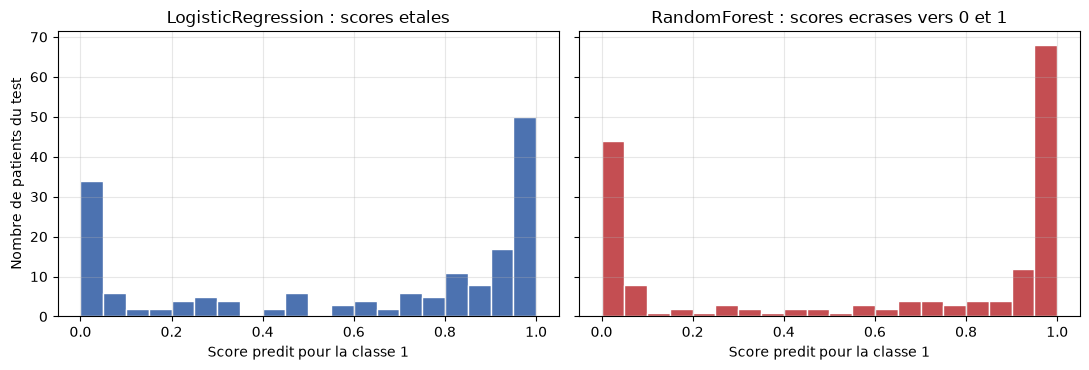

In [2]:
# Deux modeles contrastes : regression logistique (bien calibree) vs foret aleatoire (ecrasee vers 0/1)
# Les deux mesures vivent sur des echelles tres differentes (dizaines vs centiemes) : on standardise,
# comme au notebook 2.1 -- sinon la regularisation L2 penalise injustement la dimension fractale.
lr = Pipeline(
    [("sc", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))]
).fit(X_train, y_train)
rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

proba_lr = lr.predict_proba(X_test)[:, 1]
proba_rf = rf.predict_proba(X_test)[:, 1]

# Contraste chiffre : moyenne des scores vs part des scores vivant au centre (hors extremes)
contrast = pd.DataFrame(
    {
        "mean_proba_class_1": [proba_lr.mean(), proba_rf.mean()],
        "count_pred_class_1": [int((proba_lr >= 0.5).sum()), int((proba_rf >= 0.5).sum())],
        "part_scores_dans_[0.1, 0.9]": [
            float(((proba_lr >= 0.1) & (proba_lr <= 0.9)).mean()),
            float(((proba_rf >= 0.1) & (proba_rf <= 0.9)).mean()),
        ],
    },
    index=["LogisticRegression", "RandomForest"],
).round(3)
print(contrast.to_string())

# Histogrammes : LR etalee sur [0, 1], RF bi-modale ecrasee contre 0 et 1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
bins = np.linspace(0, 1, 21)
axes[0].hist(proba_lr, bins=bins, color="#4c72b0", edgecolor="white")
axes[0].set_title("LogisticRegression : scores etales")
axes[1].hist(proba_rf, bins=bins, color="#c44e52", edgecolor="white")
axes[1].set_title("RandomForest : scores ecrases vers 0 et 1")
for ax in axes:
    ax.set_xlabel("Score predit pour la classe 1")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Nombre de patients du test")
plt.tight_layout()
plt.show()


## 2. Le reliability diagram : le construire from scratch

L'histogramme ci-dessus montre le symptôme — des moyennes proches, des distributions radicalement différentes : les trois quarts des scores de la forêt vivent sous 0.1 ou au-dessus de 0.9, alors que la régression logistique occupe tout l'intervalle. Mais l'histogramme ne dit pas lequel a **raison**. Le **reliability diagram** (diagramme de fiabilité) tranche. L'idée tient en une phrase : **regrouper les prédictions par niveaux de confiance et confronter chaque groupe à la réalité observée**.

Construction, bin par bin :

1. On découpe [0, 1] en **10 bins** de largeur 0.1 : [0.0, 0.1), [0.1, 0.2), ..., [0.9, 1.0].
2. Pour chaque bin, on calcule la **confiance moyenne** (moyenne des scores prédits des exemples du bin) et la **fréquence observée** (proportion réelle de classe 1 dans ce bin).
3. On trace un point par bin — *(confiance moyenne, fréquence observée)* — plus la diagonale **y = x** de calibration parfaite.

Lecture : un modèle bien calibré aligne ses points sur la diagonale — les patients à qui il promet ~0.7 sont positifs dans ~70 % des cas. Un modèle écrasé vers 0/1 produit des points **au-dessus** de la diagonale à gauche (il dit ~0.02, la réalité est plus élevée) et **en dessous** à droite (il dit ~0.98, la réalité est plus basse) : l'écart visuel **est** le défaut de calibration.

Nous l'implémentons **from scratch avec numpy** (`np.digitize` pour assigner chaque score à son bin, puis un masque et deux moyennes) plutôt qu'avec `sklearn.calibration` : c'est le seul moyen de constater qu'il n'y a aucune magie dans cet outil.


 bin_center  LR_freq  RF_freq
       0.05    0.025    0.135
       0.15    0.000    0.333
       0.25    0.444    0.250
       0.35    0.250    0.333
       0.45    0.375    0.250
       0.55    0.667    0.750
       0.65    0.833    1.000
       0.75    0.727    0.857
       0.85    0.947    0.875
       0.95    0.970    0.925


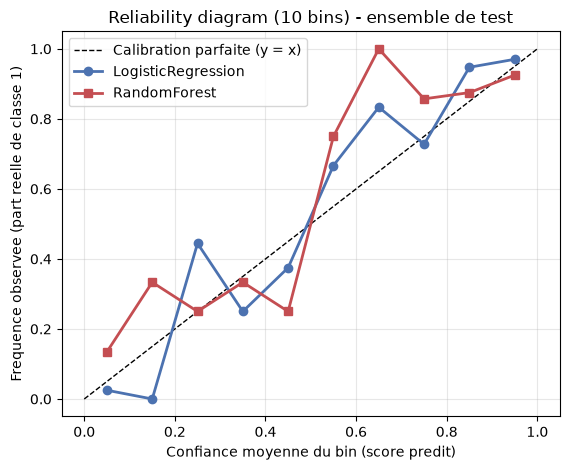

In [3]:
def reliability_diagram_data(y_true, y_proba, n_bins=10):
    """Construit les donnees du reliability diagram, bin par bin.

    Retourne (bin_centers, observed_freq) ou observed_freq[b] est la part de
    classe 1 reellement observee parmi les scores tombes dans le bin b
    (NaN si le bin est vide).
    """
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)          # [0.0, 0.1, ..., 1.0]
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])   # 0.05, 0.15, ..., 0.95
    bin_idx = np.digitize(y_proba, bin_edges[1:-1])        # 0..n_bins-1 pour chaque score
    observed_freq = np.full(n_bins, np.nan)
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            observed_freq[b] = y_true[mask].mean()
    return bin_centers, observed_freq

bin_centers, freq_lr = reliability_diagram_data(y_test, proba_lr)
_, freq_rf = reliability_diagram_data(y_test, proba_rf)

table_reliability = pd.DataFrame(
    {"bin_center": bin_centers, "LR_freq": freq_lr, "RF_freq": freq_rf}
).round(3)
print(table_reliability.to_string(index=False))

# Diagramme : un point par bin + diagonale de calibration parfaite
plt.figure(figsize=(5.8, 4.8))
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Calibration parfaite (y = x)")
plt.plot(bin_centers, freq_lr, "o-", color="#4c72b0", linewidth=2, label="LogisticRegression")
plt.plot(bin_centers, freq_rf, "s-", color="#c44e52", linewidth=2, label="RandomForest")
plt.xlabel("Confiance moyenne du bin (score predit)")
plt.ylabel("Frequence observee (part reelle de classe 1)")
plt.title("Reliability diagram (10 bins) - ensemble de test")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. ECE et Brier score : résumer le diagramme en un nombre

Le tableau et le diagramme ci-dessus se lisent d'un coup d'œil : la régression logistique colle grossièrement à la diagonale, tandis que la forêt s'en écarte aux deux extrémités — ses scores ~0.02 cachent une fréquence réelle plus élevée, et son plus gros bin (des scores ~0.98, près d'un patient sur deux du test) promet plus que ce qui s'observe réellement. Mais un diagramme ne tient pas dans un tableau de bord ni dans une comparaison automatisée. Deux chiffres le condensent :

**ECE — Expected Calibration Error.** Pour chaque bin, l'écart vertical du diagramme vaut |confiance moyenne − fréquence observée|. L'ECE agrège ces écarts en une moyenne **pondérée par la taille des bins** :

$$\mathrm{ECE} \;=\; \sum_{b=1}^{10} \frac{n_b}{n}\, \left| \, \text{confiance}_b - \text{fréquence}_b \, \right|$$

Intuition : c'est la distance moyenne au diagramme — l'écart que commet « en moyenne » le modèle entre ce qu'il promet et ce qui arrive. Un modèle parfaitement calibré a ECE = 0 ; en pratique, sur quelques centaines d'exemples de test, ECE < 0.03 est déjà très bon.

**Brier score.** La moyenne des erreurs quadratiques sur les probabilités elles-mêmes :

$$\mathrm{Brier} \;=\; \frac{1}{n} \sum_{i=1}^{n} \left( p_i - y_i \right)^2$$

Le Brier mélange les deux axes : il pénalise à la fois le mauvais ordre (discrimination) et le mauvais quantificatif (calibration) — y compris les écarts **fins**, exemple par exemple, que le binning de l'ECE lisse. On les lit donc ensemble : l'ECE isole la calibration ; le Brier juge la probabilité globale.


In [4]:
def ece_score(y_true, y_proba, n_bins=10):
    """Expected Calibration Error : somme ponderee par bin des ecarts |confiance - frequence|."""
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_idx = np.digitize(y_proba, bin_edges[1:-1])
    ece = 0.0
    for b in range(n_bins):
        mask = bin_idx == b
        if mask.any():
            confiance = y_proba[mask].mean()
            frequence = y_true[mask].mean()
            ece += mask.sum() / len(y_true) * abs(confiance - frequence)
    return float(ece)

brier_lr = float(((proba_lr - y_test) ** 2).mean())
brier_rf = float(((proba_rf - y_test) ** 2).mean())

table_scores = pd.DataFrame(
    {
        "ECE (calibration seule)": [ece_score(y_test, proba_lr), ece_score(y_test, proba_rf)],
        "Brier (calibration + discrimination)": [brier_lr, brier_rf],
    },
    index=["LogisticRegression", "RandomForest"],
).round(4)
print(table_scores.to_string())


                    ECE (calibration seule)  Brier (calibration + discrimination)
LogisticRegression                   0.0424                                0.0765
RandomForest                         0.0909                                0.1107


### Exercice 1 : mesurer l'incertitude de l'ECE avec un bootstrap

Le tableau ci-dessus chiffre le contraste : l'ECE de la forêt aléatoire est environ le double de celle de la régression logistique. Mais chaque ECE est calculée sur **un seul** ensemble de test de 171 patients — quel intervalle de confiance lui donner ?

À vous de jouer : rééchantillonnez le test **avec remise** (*bootstrap*) et recalculez l'ECE à chaque tirage pour obtenir un intervalle à 95 %.

Indices :
- # Étape 1 : tirer `n_test` indices avec remise : `tirage = rng.integers(0, n_test, n_test)`.
- # Étape 2 : sélectionner `y_test[tirage]` et `proba_rf[tirage]`, calculer `ece_score` dessus, et répéter 100 fois.
- # Étape 3 : l'intervalle à 95 % est `np.percentile(ece_echantillons, [2.5, 97.5])`.
- Lecture : si l'intervalle du RF ne recouvre pas l'ECE de la régression logistique, l'écart est robuste malgré le petit test.


In [5]:
# Exercice 1 : intervalle de confiance bootstrap a 95 % sur l'ECE du RandomForest
rng = np.random.default_rng(42)
n_test = len(y_test)
ece_echantillons = None  # TODO etudiant : liste des 100 ECE bootstrap (une par reechantillon)
# TODO etudiant : pour chaque tirage, tirage = rng.integers(0, n_test, n_test) puis
# ece_echantillons.append(ece_score(y_test[tirage], proba_rf[tirage]))
bornes = (None, None)  # TODO etudiant : remplacer (np.percentile(ece_echantillons, [2.5, 97.5]))
print(f"Exercice 1 a completer : ECE RF = {ece_score(y_test, proba_rf):.4f}, "
      f"IC 95 % = [{bornes[0]}, {bornes[1]}]")


Exercice 1 a completer : ECE RF = 0.0909, IC 95 % = [None, None]


## 4. Platt scaling : recalibrer avec… une régression logistique

Diagnostic posé, passons au traitement. L'idée la plus simple : apprendre une **transformation** qui remappe le score défectueux vers une probabilité correcte. On ajuste une régression logistique (notebook 2.3) dont l'**unique variable d'entrée est le score du modèle à corriger** — pas les mesures d'origine :

$$p_{\text{calibrée}} \;=\; \sigma\!\left(a \cdot \text{score} + b\right)$$

C'est le **Platt scaling** (Platt, 1999). Si le modèle est écrasé vers les extrêmes, la sigmoïde apprise ramène ses scores trop confiants vers leurs fréquences réelles. Faites le lien avec 2.3 : c'est exactement le même modèle, appliqué à une seule feature bien choisie — le score lui-même.

> **Règle d'or (et on l'applique).** Le calibrateur ne doit **jamais** être ajusté sur les données qui servent à l'évaluer. Nous l'ajustons donc sur les scores **out-of-fold** de l'entraînement : pour chaque patient du train, le score d'une forêt qui ne l'a **pas** vu (`cross_val_predict` à 5 plis) — exactement ce que fait `CalibratedClassifierCV(rf, method="sigmoid", cv=5)` en production. Le test reste vierge jusqu'à l'évaluation finale.


In [6]:
# Platt scaling : une regression logistique ajustee sur les SCORES out-of-fold du RF (pas sur X, pas sur le test)
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression as LR2

# Scores out-of-fold : pour chaque patient du train, le score d'une foret qui ne l'a pas vu (cv=5)
scores_oof = cross_val_predict(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train, y_train, cv=5, method="predict_proba",
)[:, 1]

platt = LR2().fit(scores_oof.reshape(-1, 1), y_train)
proba_rf_platt = platt.predict_proba(proba_rf.reshape(-1, 1))[:, 1]

a, b = platt.coef_[0, 0], platt.intercept_[0]
print(f"Sigmoide apprise : p = sigmoid({a:.3f} * score + ({b:.3f}))")
print(f"ECE RandomForest brut     : {ece_score(y_test, proba_rf):.4f}")
print(f"ECE RandomForest + Platt  : {ece_score(y_test, proba_rf_platt):.4f}")


Sigmoide apprise : p = sigmoid(4.998 * score + (-2.434))
ECE RandomForest brut     : 0.0909
ECE RandomForest + Platt  : 0.0552


## 5. Régression isotonique : la version non paramétrique

Le Platt scaling impose une **forme** (une sigmoïde, deux paramètres). La **régression isotonique** lève cette contrainte : elle apprend la fonction **croissante quelconque** (un escalier) qui colle au mieux aux données (Zadrozny & Elkan, 2002). Plus flexible, elle a besoin de **plus de données** pour ne pas apprendre le bruit — ici, l'escalier s'ajuste sur 398 scores out-of-fold, et une grande masse d'entre eux est écrasée dans les mêmes bins : c'est le régime défavorable à une méthode non paramétrique. Regardons ce que ça donne — la théorie ne promet pas que « plus flexible » gagne toujours.

Les deux transformations partagent une propriété cruciale : elles sont **croissantes**. Un score plus élevé reste une probabilité plus élevée. Visualisons la carte de calibration apprise par chaque méthode.


ECE RandomForest brut      : 0.0909
ECE RandomForest + Platt   : 0.0552
ECE RandomForest + isoto.  : 0.0941


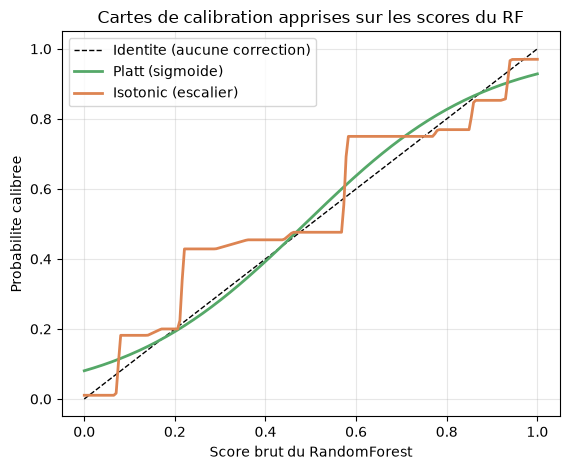

In [7]:
# Regression isotonique : transformation croissante non parametrique, ajustee sur les memes scores OOF
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds="clip").fit(scores_oof, y_train)
proba_rf_iso = np.clip(iso.predict(proba_rf), 0.0, 1.0)

print(f"ECE RandomForest brut      : {ece_score(y_test, proba_rf):.4f}")
print(f"ECE RandomForest + Platt   : {ece_score(y_test, proba_rf_platt):.4f}")
print(f"ECE RandomForest + isoto.  : {ece_score(y_test, proba_rf_iso):.4f}")

# Les deux transformations apprises : toutes deux croissantes (l'ordre est preserve)
grille = np.linspace(0.0, 1.0, 200)
plt.figure(figsize=(5.8, 4.8))
plt.plot(grille, grille, "k--", linewidth=1, label="Identite (aucune correction)")
plt.plot(grille, platt.predict_proba(grille.reshape(-1, 1))[:, 1],
         color="#55a868", linewidth=2, label="Platt (sigmoide)")
plt.plot(grille, np.clip(iso.predict(grille), 0.0, 1.0),
         color="#dd8452", linewidth=2, label="Isotonic (escalier)")
plt.xlabel("Score brut du RandomForest")
plt.ylabel("Probabilite calibree")
plt.title("Cartes de calibration apprises sur les scores du RF")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Ce que la calibration ne change PAS

Un mot d'abord sur le résultat de la section 5 : la sigmoïde contrainte du Platt réduit l'ECE de 40 % (0.091 → 0.055), tandis que l'escalier libre de l'isotonique stagne (0.094) — la flexibilité non paramétrique surapprend 398 scores de calibration dont la masse est écrasée dans deux bins. Avec dix fois plus de données, l'escalier prendrait sa revanche ; ici, la contrainte gagne. C'est une leçon générale : le calibrateur, lui aussi, est un modèle, avec son propre compromis biais-variance.

Regardez maintenant la figure ci-dessus : les deux cartes sont **croissantes**. Conséquence mécanique : elles **préservent l'ordre** des exemples. Le patient le plus à risque avant calibration l'est toujours après. Trois corollaires à vérifier :

1. **L'AUC est préservée par Platt** : la sigmoïde apprise est strictement croissante, elle ne dépend que de l'ordre, pas des valeurs — l'AUC du RF brut et du RF calibré Platt doivent coïncider. L'isotonique, elle, apprend un **escalier** : ses marches créent des **égalités** (deux scores distincts ramenés à la même valeur), ce qui peut coûter un peu d'AUC.
2. **La discrimination est préservée** : si le modèle était le meilleur en AUC, il le reste. La calibration n'améliore pas le classement — elle rend les scores *interprétables comme des probabilités*.
3. **Le seuil 0.5 calibré correspond à un seuil différent sur le score brut** : $p_{\text{cal}} \geq 0.5 \Leftrightarrow \text{score} \geq -b/a$ avec le Platt scaling. Si ce nouveau seuil tombe dans une zone presque vide de l'histogramme de la section 1, **aucun** patient ne change de prédiction au seuil 0.5 — mais c'est une coïncidence empirique, pas une garantie : le seuil de référence sur le score brut, lui, a bel et bien bougé.

Le message : **calibrer ne « répare » pas un modèle** — cela l'équipe d'un thermomètre honnête. Un modèle mal calibré mais bien ordonnant était déjà un bon *trieur* de patients ; il était un mauvais *pronostiqueur*.


In [8]:
# L'ordre est preserve : AUC conservees, decisions au seuil 0.5 quasi identiques
auc_brut = roc_auc_score(y_test, proba_rf)
auc_platt = roc_auc_score(y_test, proba_rf_platt)
auc_iso = roc_auc_score(y_test, proba_rf_iso)
print(f"AUC RF brut     : {auc_brut:.4f}")
print(f"AUC RF + Platt  : {auc_platt:.4f}")
print(f"AUC RF + isoto. : {auc_iso:.4f}")

pred_brut = (proba_rf >= 0.5).astype(int)
pred_platt = (proba_rf_platt >= 0.5).astype(int)
pred_iso = (proba_rf_iso >= 0.5).astype(int)
print(f"\nPredictions basculant au seuil 0.5, brut -> Platt    : {int(np.sum(pred_brut != pred_platt))}")
print(f"Predictions basculant au seuil 0.5, brut -> isotonic : {int(np.sum(pred_brut != pred_iso))}")


AUC RF brut     : 0.9129


AUC RF + Platt  : 0.9129
AUC RF + isoto. : 0.9000

Predictions basculant au seuil 0.5, brut -> Platt    : 0
Predictions basculant au seuil 0.5, brut -> isotonic : 3


### Exercice 2 : la température, le Platt scaling des réseaux de neurones

Les réseaux de neurones produisent des **logits** $z$ avant le softmax, et les logits des réseaux modernes sont notoirement **surconfiants**. Le **temperature scaling** (Guo et al., 2017) divise les logits par une température $T$ avant le softmax :

$$\text{softmax}(z / T)$$

- $T > 1$ : le softmax **ramollit** — les probabilités quittent les extrêmes (réseau surconfiant).
- $T < 1$ : le softmax **durcit** — probabilités plus tranchées (réseau sous-confiant).

C'est un Platt scaling à un paramètre (pente $1/T$, pas d'ordonnée à l'origine) appliqué aux logits. Le $T$ optimal est celui qui minimise la log-vraisemblance négative (NLL) sur un jeu de validation.

Le code ci-dessous simule un réseau **surconfiant** : les labels de validation ont été générés avec une vraie température de 2 (les logits sont deux fois trop grands pour la réalité). À vous de retrouver $T$.

Indices :
- # Étape 1 : probabilité = `1 / (1 + np.exp(-logits / T))` (le softmax binaire est une sigmoïde).
- # Étape 2 : NLL = `-np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))`, en protégeant les logs (`np.clip(p, 1e-12, 1 - 1e-12)`).
- # Étape 3 : balayer `T` sur `np.linspace(0.5, 5.0, 91)` et garder le minimisateur.


In [9]:
# Exercice 2 : retrouver la temperature optimale d'un reseau surconfiant
rng = np.random.default_rng(0)
n_val = 500
logits_reseau = rng.normal(loc=1.5, scale=1.0, size=n_val)   # logits surconfiants
p_vraie = 1.0 / (1.0 + np.exp(-logits_reseau / 2.0))         # vraie temperature : T = 2
y_val = (rng.random(n_val) < p_vraie).astype(int)            # labels de validation simules

def nll_temperature(T, logits, y):
    # TODO etudiant : probabilite = sigmoid(logits / T), retourner la NLL moyenne
    return None  # TODO etudiant : remplacer

T_optimal = None  # TODO etudiant : argmin de nll_temperature sur np.linspace(0.5, 5.0, 91)
print(f"Exercice 2 a completer : T optimal = {T_optimal} (vrai T = 2.0)")


Exercice 2 a completer : T optimal = None (vrai T = 2.0)


## 7. Usage en aval : espérance de gain avec probabilités calibrées vs brutes

Pourquoi tant d'effort ? Parce qu'en aval, on ne consomme presque jamais un score seul : on le branche dans un **calcul de décision**. Mini-cas médical : un traitement coûte **100**, rapporte **200** s'il est donné à un patient réellement positif, et rien sinon. L'espérance de gain en traitant un patient de probabilité $p$ :

$$\mathrm{EV}(p) \;=\; 200 \cdot p - 100$$

On traite si $\mathrm{EV} > 0$, c'est-à-dire $p > 0.5$. Le point clé : l'espérance dépend **linéairement** de $p$ — une forêt surconfiante qui annonce ~0.98 là où la fréquence réelle du bin est ~0.93 promet EV = +96 quand l'espérance honnête est +86. Le classement des patients est identique ; le **chiffre présenté au décideur** est faux.

Comparons, sur les 10 patients de test dont le score RF est le plus proche de 0.5 (la zone où la décision se joue), l'espérance calculée avec les probabilités brutes vs recalibrées par Platt.


In [10]:
# Esperance de gain : probabilites brutes vs calibrees, sur les 10 patients les plus borderline
cout_traitement, benefice_si_positif = 100.0, 200.0

idx_bord = np.argsort(np.abs(proba_rf - 0.5))[:10]   # les 10 scores les plus proches du seuil

ev_brutes = benefice_si_positif * proba_rf[idx_bord] - cout_traitement
ev_platt = benefice_si_positif * proba_rf_platt[idx_bord] - cout_traitement

table_ev = pd.DataFrame(
    {
        "proba_RF_brute": proba_rf[idx_bord].round(3),
        "proba_RF_Platt": proba_rf_platt[idx_bord].round(3),
        "classe_reelle": y_test[idx_bord],
        "EV_brute": ev_brutes.round(1),
        "EV_Platt": ev_platt.round(1),
    }
)
print(table_ev.to_string(index=False))
print(f"\nEV moyenne (10 patients) avec probabilites brutes    : {ev_brutes.mean():+.1f}")
print(f"EV moyenne (10 patients) avec probabilites calibrees : {ev_platt.mean():+.1f}")


 proba_RF_brute  proba_RF_Platt  classe_reelle  EV_brute  EV_Platt
           0.48           0.491              0      -4.0      -1.7
           0.53           0.554              0       6.0      10.7
           0.46           0.466              0      -8.0      -6.7
           0.55           0.578              1      10.0      15.6
           0.44           0.442              1     -12.0     -11.7
           0.56           0.590              1      12.0      18.1
           0.58           0.614              1      16.0      22.8
           0.42           0.417              0     -16.0     -16.6
           0.61           0.649              1      22.0      29.8
           0.61           0.649              1      22.0      29.8

EV moyenne (10 patients) avec probabilites brutes    : +4.8
EV moyenne (10 patients) avec probabilites calibrees : +9.0


### Exercice 3 (capstone) : le seuil qui maximise l'espérance

La cellule précédente calcule l'espérance *si l'on traite tous* les patients borderline. L'exercice est de choisir **qui traiter** : balayer le seuil de décision $s$ (traiter si $p \geq s$) et trouver celui qui maximise le gain **total** sur l'ensemble de test, avec les probabilités **calibrées** (Platt). C'est la généralisation calculée de la section 7 du notebook 2.5, où le seuil était posé à la main selon le coût des erreurs.

Indices :
- # Étape 1 : pour un seuil `s`, les décisions sont `probas >= s`.
- # Étape 2 : gain = `+(benefice - cout)` si traité et `y == 1`, `-cout` si traité et `y == 0`, `0` sinon (vectoriser avec `np.where`).
- # Étape 3 : balayer `seuils` avec `proba_rf_platt` et `y_test`, garder le `s` du gain total maximal.
- Question bonus : le seuil optimal diffère-t-il de celui obtenu avec les probabilités brutes ? (Repensez à la section 6 : l'ordre est préservé… mais le seuil 0.5 calibré correspond à un autre seuil sur le score brut.)


In [11]:
# Exercice 3 (capstone) : seuil qui maximise l'esperance de gain sur le test (probabilites calibrees)
seuils = np.linspace(0.01, 0.99, 99)

def gain_total(seuil, probas, y, cout=100.0, benefice=200.0):
    # TODO etudiant : traiter si probas >= seuil ; +(benefice - cout) si y == 1, -cout si y == 0, 0 sinon
    return None  # TODO etudiant : remplacer

meilleur_seuil = None  # TODO etudiant : argmax de gain_total sur seuils, avec proba_rf_platt et y_test
print(f"Exercice 3 a completer : seuil d'esperance maximale = {meilleur_seuil}")


Exercice 3 a completer : seuil d'esperance maximale = None


## Synthèse et transition

Trois leçons à retenir :

1. **Bien calibré ≠ bon classement.** L'AUC ne voit que l'ordre des exemples ; la calibration demande en plus que le score se comporte comme une fréquence. La régression logistique sort souvent bien calibrée ; les ensembles d'arbres écrasent leurs scores vers 0 et 1 — surtout quand les classes se chevauchent. Le reliability diagram expose l'écart ; l'ECE et le Brier le chiffrent.
2. **La calibration préserve l'ordre.** Platt et isotonic sont des transformations croissantes : l'AUC Platt reste identique et, tant que les scores extrêmes dominent, le seuil 0.5 ne bascule quasiment aucune prédiction. Calibrer n'améliore pas le modèle — cela rend ses scores interprétables comme des probabilités.
3. **Consommer une probabilité non calibrée = décision sous-optimale.** Dès qu'une espérance de gain, un prix ou un niveau de risque se calcule à partir du score, la surconfiance du modèle se propage telle quelle dans le chiffre présenté au décideur.

Transition : avec la classification, ses métriques (2.5) et ses probabilités calibrées, nous avons épuisé le cas « données étiquetées ». Le notebook suivant (`2.6-Clustering-KMeans-PCA`) quitte le supervisé pour le **non supervisé** : regrouper des exemples sans étiquettes (**KMeans**) et compresser les variables (**PCA**).


## References

1. Niculescu-Mizil, A. & Caruana, R. (2005). *Predicting Good Probabilities With Supervised Learning*. ICML 2005. — La calibration par famille de modèles : régression logistique bien calibrée, arbres écrasés vers 0 et 1.
2. Platt, J. (1999). *Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods*. Advances in Large Margin Classifiers. — Le Platt scaling : une sigmoïde apprise sur les scores.
3. Zadrozny, B. & Elkan, C. (2002). *Transforming Classifier Scores into Accurate Multiclass Probability Estimates*. KDD 2002. — La régression isotonique comme calibration non paramétrique.
4. Guo, C., Pleiss, G., Sun, Y. & Weinberger, K. (2017). *On Calibration of Modern Neural Networks*. ICML 2017. — Reliability diagrams, ECE et temperature scaling pour les réseaux de neurones.
5. Brier, G. W. (1950). *Verification of Forecasts Expressed in Terms of Probability*. Monthly Weather Review 78(1):1-3. — Le score de Brier, venu de la prévision météorologique.
